# Market Differentiated Bars

## Overview

This notebook demonstrates the public functions in `market_differentiated_bars`.

- Problem: integer differencing can remove more memory than is needed to make a price series stationary.
- Approach: diagnose a minimum stationary differencing order for the configured bar type and apply that order to its log-close series.

## Observed Data

This cell loads one observed market-bar dataset selected through reusable file-name settings.

- `feature_dir` identifies the source and output directory at `../../data/research_data/market/features`.
- `symbol_slug` identifies the instrument in source and output file names.
- `bar_type` selects the market-bar construction used in source and output file names.
- `period_slug` identifies the inclusive observation period in source and output file names.
- `bar_label` provides the title-cased bar description used in plot titles.
- `data_path` identifies the configured observed market-bar Parquet file.
- `bars` contains the configured observed market bars.
- `end` identifies each bar's final source timestamp in UTC.
- `close` contains each bar's final observed price in dollars.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.data_preprocessing.market_differentiated_bars import (
    fractional_difference_fixed_width,
    plot_min_ffd,
)

feature_dir = Path(
    "../../data/research_data/market/features"
)
symbol_slug = "aapl"
bar_type = "dollar_bar"
period_slug = "2025-01-01_2025-12-31"
bar_label = bar_type.replace("_", " ").title()

data_path = feature_dir / (
    f"{symbol_slug}_{bar_type}_{period_slug}.parquet"
)
bars = pd.read_parquet(data_path)

display(bars[["end", "close"]].head())

,end,close
0,2025-01-02 14:30:01.004279+00:00,248.91
1,2025-01-02 14:30:02.119118+00:00,248.65
2,2025-01-02 14:30:02.891073+00:00,248.59
3,2025-01-02 14:30:04.394582+00:00,248.61
4,2025-01-02 14:30:05.084156+00:00,248.58


## Minimum Differencing Diagnostic

This cell identifies the minimum fixed-width fractional-differencing order whose transformed log-close series rejects a unit root at the 5% level.

- `close_frame` contains the configured bar's final prices in dollars.
- `log_close_frame` contains the natural logarithm of each strictly positive `close` value.
- `weight_cutoff` sets the absolute fixed-width weight cutoff used for every evaluated order.
- `differencing_orders` contains the candidate orders from `0.0` through `1.0` in increments of `0.1`.
- `minimum_ffd_diagnostic` reports stationarity and memory retention for each candidate order.
- `stationary_orders` contains the orders whose `adf_statistic` is below `critical_value_5pct`.
- `selected_d` is the smallest order that rejects the unit-root null hypothesis at the 5% level.
- `adf_statistic` contains the augmented Dickey-Fuller statistic for each order.
- `p_value` contains the unit-root test p-value.
- `used_lags` contains the number of lagged differences included by the test.
- `n_observations` contains the number of observations used by the test.
- `critical_value_5pct` contains the 5% critical value for rejecting a unit root.
- `correlation` contains the correlation between the transformed series and the original log-close series.
- The horizontal axis represents the fractional-differencing order.
- The primary vertical axis represents `correlation`, and the secondary vertical axis represents `adf_statistic`.
- The dotted horizontal line marks the mean `critical_value_5pct`, so the first statistic below it identifies `selected_d`.

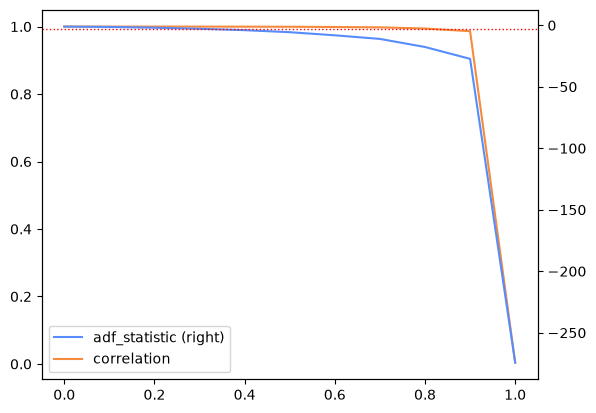

Selected differencing order: 0.4


,adf_statistic,p_value,used_lags,n_observations,critical_value_5pct,correlation
0.0,-1.066527,7.282344e-01,1.0,156777.0,-2.861558,1.000000
0.1,-1.374186,5.945874e-01,1.0,156770.0,-2.861558,0.999997
0.2,-1.975255,2.975270e-01,1.0,156767.0,-2.861558,0.999972
0.3,-2.858396,5.040428e-02,1.0,156766.0,-2.861558,0.999899
0.4,-3.977197,1.534738e-03,1.0,156767.0,-2.861558,0.999757
0.5,-5.625967,1.117234e-06,1.0,156768.0,-2.861558,0.999457
0.6,-8.150996,9.697085e-13,1.0,156769.0,-2.861558,0.998792
0.7,-11.092545,4.048186e-20,1.0,156771.0,-2.861558,0.997763
0.8,-17.654490,3.706856e-30,1.0,156772.0,-2.861558,0.994239
0.9,-27.297711,0.000000e+00,1.0,156774.0,-2.861558,0.986353


In [2]:
close_frame = bars[["close"]].astype(float)
log_close_frame = np.log(
    close_frame
).rename(columns={"close": "log_close"})

weight_cutoff = 0.01
differencing_orders = np.linspace(0.0, 1.0, 11)

minimum_ffd_diagnostic = plot_min_ffd(
    log_close_frame,
    weight_cutoff=weight_cutoff,
    differencing_orders=differencing_orders,
)
stationary_orders = minimum_ffd_diagnostic.index[
    minimum_ffd_diagnostic["adf_statistic"]
    < minimum_ffd_diagnostic["critical_value_5pct"]
]
selected_d = stationary_orders.min()

print(f"Selected differencing order: {selected_d:.1f}")
minimum_ffd_diagnostic

## Fractional Difference

This cell applies the selected order to the configured log-close series, saves the retained values, and visualizes only the transformed series.

- `fractionally_differenced_log_close` contains the transformed log-close values at retained source row positions.
- `fractional_bars` aligns each transformed value with its original UTC endpoint.
- `end` identifies the original bar endpoint in UTC and can contain repeated timestamps.
- `fractionally_differenced_log_close` contains the fixed-width fractional difference in log-price units.
- `fractional_output_path` identifies the saved Parquet result and preserves the configured `bar_type` in its file name.
- The horizontal axis represents the original bar `end` timestamp in UTC.
- The vertical axis represents `fractionally_differenced_log_close`.

../../data/research_data/market/features/aapl_dollar_bar_fractional_2025-01-01_2025-12-31.parquet


,end,fractionally_differenced_log_close
10,2025-01-02 14:30:41.213855+00:00,1.456864
11,2025-01-02 14:30:51.377662+00:00,1.455722
12,2025-01-02 14:31:11.718819+00:00,1.459324
13,2025-01-02 14:31:19.128211+00:00,1.456683
14,2025-01-02 14:31:36.970130+00:00,1.455564


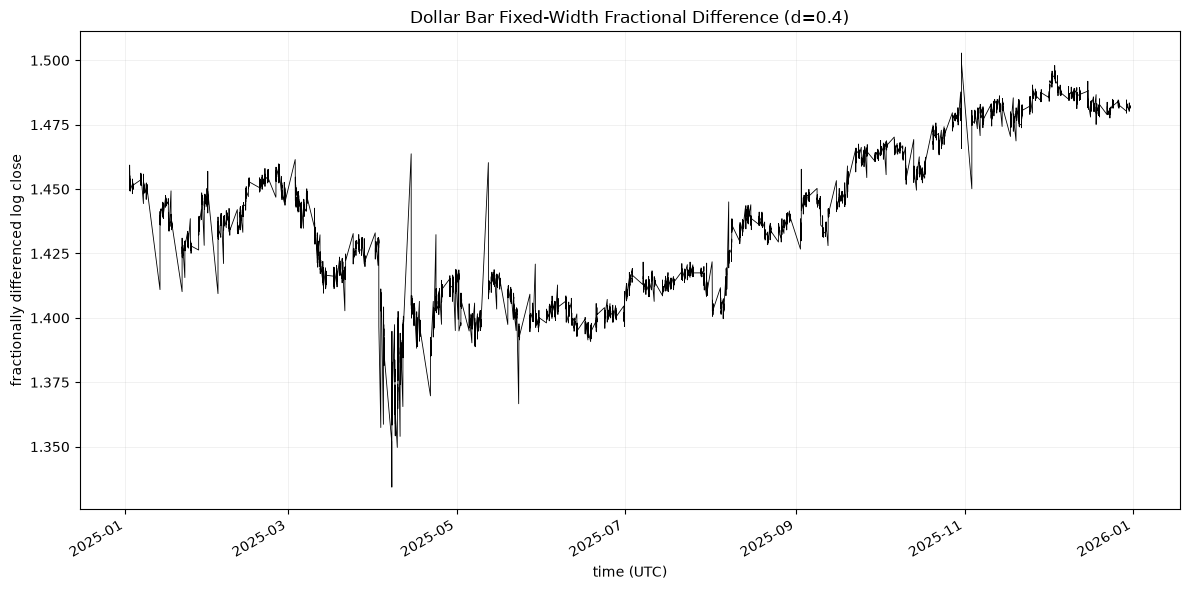

In [3]:
fractionally_differenced_log_close = (
    fractional_difference_fixed_width(
        log_close_frame,
        differencing_order=selected_d,
        weight_cutoff=weight_cutoff,
    )
)
fractional_bars = bars.loc[
    fractionally_differenced_log_close.index,
    ["end"],
].copy()
fractional_bars[
    "fractionally_differenced_log_close"
] = fractionally_differenced_log_close["log_close"]

fractional_output_path = feature_dir / (
    f"{symbol_slug}_{bar_type}_fractional_{period_slug}.parquet"
)
fractional_bars.to_parquet(
    fractional_output_path,
    index=False,
)

print(fractional_output_path)
display(fractional_bars.head())

figure, axis = plt.subplots(figsize=(12, 6))
fractional_bars.set_index("end")[
    "fractionally_differenced_log_close"
].plot(ax=axis, color="black", linewidth=0.6)
axis.set_xlabel("time (UTC)")
axis.set_ylabel("fractionally differenced log close")
axis.set_title(
    f"{bar_label} Fixed-Width Fractional Difference "
    f"(d={selected_d:.1f})"
)
axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()